In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv(r
"C:\Users\DELL\Desktop\train_features.csv")


df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


In [6]:

missing_data = df.isnull().sum()
print("Columns zenye missing values:")
print(missing_data[missing_data > 0])

print("\nJumla ya duplicates:", df.duplicated().sum())

Columns zenye missing values:
funder                3637
installer             3655
wpt_name                 2
subvillage             371
public_meeting        3334
scheme_management     3878
scheme_name          28810
permit                3056
dtype: int64

Jumla ya duplicates: 0


In [7]:

df = df.drop(columns=['scheme_name'])


cols_to_fill = ['funder', 'installer', 'wpt_name', 'subvillage', 'public_meeting', 'scheme_management', 'permit']

for col in cols_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

print("Jumla ya missing values zilizobaki:", df.isnull().sum().sum())

Jumla ya missing values zilizobaki: 0


In [8]:

print("Idadi ya latitude zisizo sahihi (karibu na 0):", (df['latitude'] > -1e-8).sum())


df['latitude'] = df['latitude'].replace(0, np.nan)
df['longitude'] = df['longitude'].replace(0, np.nan)

df['latitude'] = df['latitude'].fillna(df['latitude'].median())
df['longitude'] = df['longitude'].fillna(df['longitude'].median())


df.to_csv('cleaned_train_features.csv', index=False)
print("\nData cleaning imekamilika! Faili la 'cleaned_train_features.csv' limehifadhiwa.")

Idadi ya latitude zisizo sahihi (karibu na 0): 0

Data cleaning imekamilika! Faili la 'cleaned_train_features.csv' limehifadhiwa.


In [9]:

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,59400.0,37115.131768,21453.128371,0.000000,18519.750000,37061.500000,55656.500000,7.424700e+04
amount_tsh,59400.0,317.650385,2997.574558,0.000000,0.000000,0.000000,20.000000,3.500000e+05
gps_height,59400.0,668.297239,693.116350,-90.000000,0.000000,369.000000,1319.250000,2.770000e+03
longitude,59400.0,35.145285,2.567468,29.607122,33.354079,35.005943,37.178387,4.034519e+01
latitude,59400.0,-5.706033,2.946019,-11.649440,-8.540621,-5.021597,-3.326156,-2.000000e-08
num_private,59400.0,0.474141,12.236230,0.000000,0.000000,0.000000,0.000000,1.776000e+03
region_code,59400.0,15.297003,17.587406,1.000000,5.000000,12.000000,17.000000,9.900000e+01
district_code,59400.0,5.629747,9.633649,0.000000,2.000000,3.000000,5.000000,8.000000e+01
population,59400.0,179.909983,471.482176,0.000000,0.000000,25.000000,215.000000,3.050000e+04
construction_year,59400.0,1300.652475,951.620547,0.000000,0.000000,1986.000000,2004.000000,2.013000e+03


In [10]:

categorical_cols = ['quantity', 'waterpoint_type', 'extraction_type_group', 'water_quality']

for col in categorical_cols:
    print(f"--- Value Counts for: {col} ---")
    print(df[col].value_counts())
    print("\n")

--- Value Counts for: quantity ---
quantity
enough          33186
insufficient    15129
dry              6246
seasonal         4050
unknown           789
Name: count, dtype: int64


--- Value Counts for: waterpoint_type ---
waterpoint_type
communal standpipe             28522
hand pump                      17488
other                           6380
communal standpipe multiple     6103
improved spring                  784
cattle trough                    116
dam                                7
Name: count, dtype: int64


--- Value Counts for: extraction_type_group ---
extraction_type_group
gravity            26780
nira/tanira         8154
other               6430
submersible         6179
swn 80              3670
mono                2865
india mark ii       2400
afridev             1770
rope pump            451
other handpump       364
other motorpump      122
wind-powered         117
india mark iii        98
Name: count, dtype: int64


--- Value Counts for: water_quality ---
water_qual

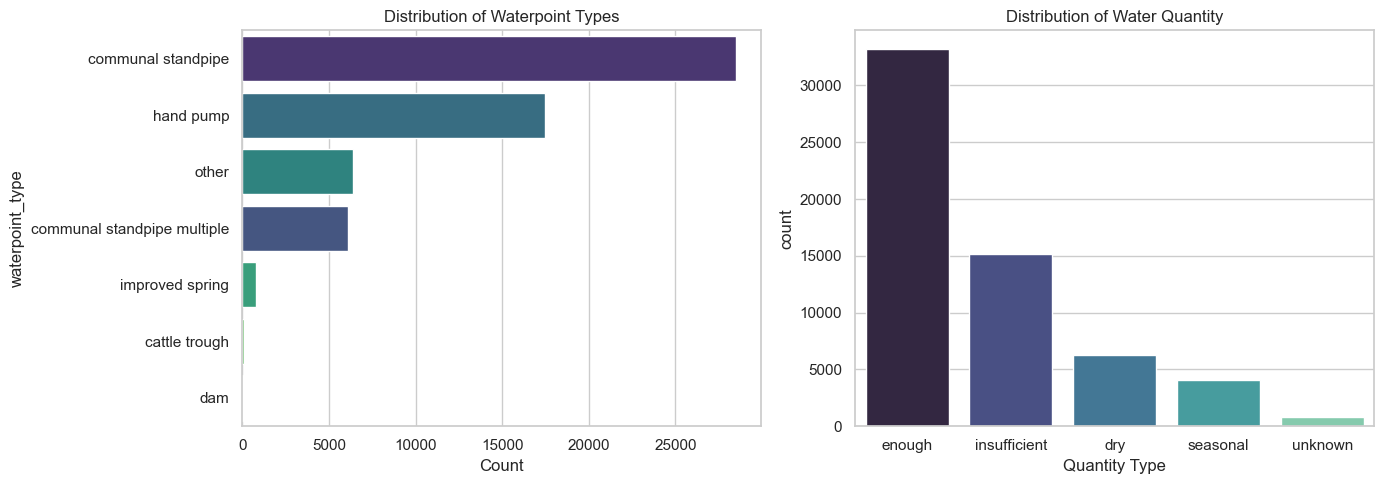

In [12]:
import warnings
warnings.filterwarnings('ignore')  
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 5))

# Plot 1: Waterpoint types
plt.subplot(1, 2, 1)
sns.countplot(
    y='waterpoint_type', 
    hue='waterpoint_type', 
    data=df, 
    order=df['waterpoint_type'].value_counts().index, 
    palette='viridis', 
    legend=False
)
plt.title('Distribution of Waterpoint Types')
plt.xlabel('Count')


plt.subplot(1, 2, 2)
sns.countplot(
    x='quantity', 
    hue='quantity', 
    data=df, 
    order=df['quantity'].value_counts().index, 
    palette='mako', 
    legend=False
)
plt.title('Distribution of Water Quantity')
plt.xlabel('Quantity Type')

plt.tight_layout()
plt.show()

In [13]:
df['date_recorded'] = pd.to_datetime(df['date_recorded'])
df['year_recorded'] = df['date_recorded'].dt.year

df['pump_age'] = df['year_recorded'] - df['construction_year']
df['pump_age'] = df['pump_age'].apply(lambda x: np.nan if x > 100 or x < 0 else x)
df['pump_age'] = df['pump_age'].fillna(df['pump_age'].median())

df[['construction_year', 'year_recorded', 'pump_age']].head()

,construction_year,year_recorded,pump_age
0,1999,2011,12.0
1,2010,2013,3.0
2,2009,2013,4.0
3,1986,2013,27.0
4,0,2011,13.0


In [39]:
high_cardinality_cols = ['id', 'funder', 'installer', 'wpt_name', 'subvillage', 'ward', 'recorded_by', 'date_recorded']

df = df.drop(columns=[col for col in high_cardinality_cols if col in df.columns])

print("Shape ya dataset sasa:", df.shape)
df.head(2)

NameError: name 'df' is not defined

In [16]:
categorical_features = df.select_dtypes(include=['object']).columns

df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print("Shape ya dataset baada ya One-Hot Encoding:", df_encoded.shape)
df_encoded.head(2)

Shape ya dataset baada ya One-Hot Encoding: (59400, 288)


,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year,year_recorded,...,waterpoint_type_communal standpipe multiple,waterpoint_type_dam,waterpoint_type_hand pump,waterpoint_type_improved spring,waterpoint_type_other,waterpoint_type_group_communal standpipe,waterpoint_type_group_dam,waterpoint_type_group_hand pump,waterpoint_type_group_improved spring,waterpoint_type_group_other
0,6000.0,1390,34.938093,-9.856322,0,11,5,109,1999,2011,...,False,False,False,False,False,True,False,False,False,False
1,0.0,1399,34.698766,-2.147466,0,20,2,280,2010,2013,...,False,False,False,False,False,True,False,False,False,False
